DATASET LOADED
  Rows    : 307,511
  Columns : 122

TARGET VARIABLE : TARGET
  0 = Loan repaid on time (no default)
  1 = Client had payment difficulties (default)

Value counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate : 8.07%
Non-default  : 91.93%


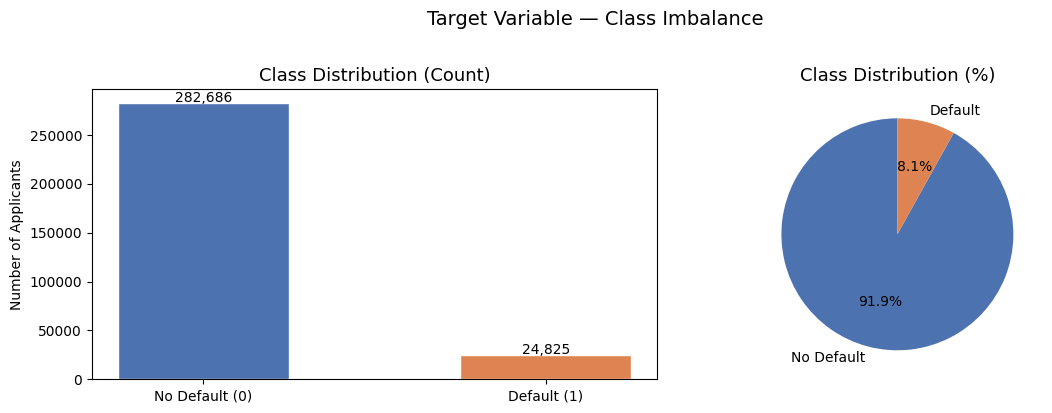


Chart saved as class_imbalance.png


In [2]:
# ─────────────────────────────────────────────────────────────
# STEP 1 — PROBLEM FORMULATION
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load the main training table ──────────────────────────────
df = pd.read_csv("D:\\home-credit-default-risk\\data\\application_train.csv")

print("=" * 60)
print("DATASET LOADED")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("=" * 60)

# ── Target Variable ───────────────────────────────────────────
print("\nTARGET VARIABLE : TARGET")
print("  0 = Loan repaid on time (no default)")
print("  1 = Client had payment difficulties (default)")
print("\nValue counts:")
print(df["TARGET"].value_counts())

# ── Class Imbalance ───────────────────────────────────────────
target_counts = df["TARGET"].value_counts()
default_rate  = df["TARGET"].mean() * 100

print(f"\nDefault rate : {default_rate:.2f}%")
print(f"Non-default  : {100 - default_rate:.2f}%")

# ── Visualise Class Imbalance ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(
    ["No Default (0)", "Default (1)"],
    target_counts.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white",
    width=0.5
)
axes[0].set_title("Class Distribution (Count)", fontsize=13)
axes[0].set_ylabel("Number of Applicants")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=["No Default", "Default"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90
)
axes[1].set_title("Class Distribution (%)", fontsize=13)

plt.suptitle("Target Variable — Class Imbalance", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as class_imbalance.png")

# ── Evaluation Metrics Explanation ───────────────────────────

1. ROC-AUC (Area Under the ROC Curve)
   ─────────────────────────────────────
   Measures how well the model RANKS applicants by risk.
   AUC = 0.5 → random guessing
   AUC = 1.0 → perfect separation
   WHY: Works well even with class imbalance. A bank cares
        about ranking risk correctly, not just classifying.

2. KS Statistic (Kolmogorov-Smirnov)
   ─────────────────────────────────────
   Maximum separation between the cumulative distribution
   of defaulters vs non-defaulters across score deciles.
   WHY: Standard metric in credit risk industry. Directly
        tells you how well the model separates good vs bad.
   KS > 40% is considered a strong model in banking.

3. Business Loss Function
   ─────────────────────────────────────
   Cost of False Negative (missed default) >> 
   Cost of False Positive (rejected good customer)
   
   Example:
     Loan amount       = ₹5,00,000
     False Negative    = bank loses ₹5,00,000
     False Positive    = bank loses ₹15,000 (interest income)
   
   WHY: Pure accuracy is useless at 8% default rate.
        We optimize threshold to minimize total business loss.
=============================================================


# ── Problem Type Summary ──────────────────────────────────────
ML PROBLEM TYPE
===============
Binary Classification
  Input  : Applicant features (income, age, credit history...)
  Output : Probability of default P(TARGET=1)
  
  We output a PROBABILITY (0 to 1), not just 0/1.
  The probability is then converted to a decision using
  a threshold optimized for business cost (Step 9).